<a href="https://colab.research.google.com/github/anmollate/Data-Science/blob/main/Standardization_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn as sk

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/nileshely/Consumer-s-Buying-Behavior/refs/heads/main/social_ads.csv")

In [ ]:
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
x=df[['Age','EstimatedSalary']]

In [ ]:
y=df['Purchased']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
import matplotlib.pyplot as plt

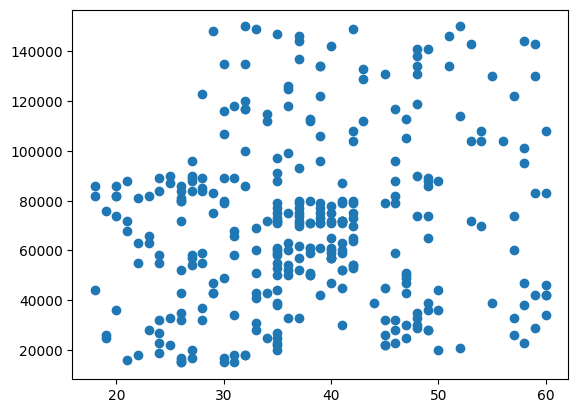

In [ ]:
plt.scatter(x_train['Age'], x_train['EstimatedSalary'])

# Now Standardizing The Values

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaler.fit(x_train)

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

#converting the x_test_scaled and x_train_scaled values to dataframe as they are in numpy array

In [ ]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=['Age','EstimatedSalary'])
x_test_scaled=pd.DataFrame(x_test_scaled,columns=['Age','EstimatedSalary'])

Text(0.5, 1.0, 'Before Scaling')

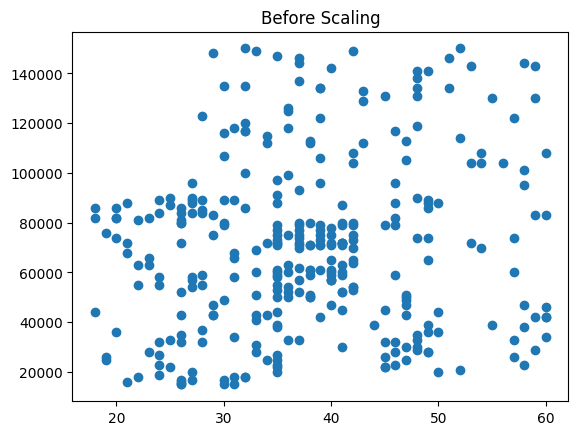

In [ ]:
#plot before scaling
plt.scatter(x_train['Age'],x_train['EstimatedSalary'])
plt.title("Before Scaling")

Text(0.5, 1.0, 'After Scaling')

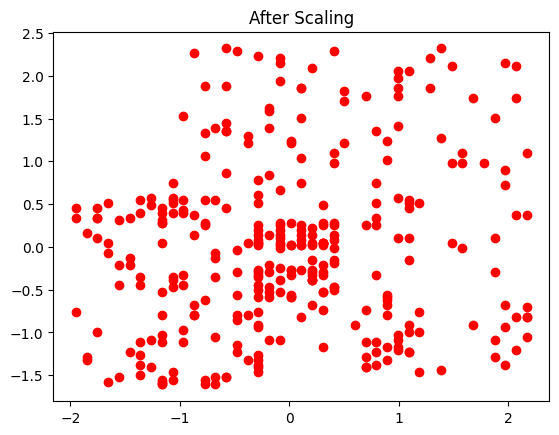

In [ ]:
#plot after scaling
plt.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
plt.title("After Scaling")

In [ ]:
x_train.describe()

,Age,EstimatedSalary
count,320.000000,320.00000
mean,37.871875,70281.25000
std,10.207525,34430.55286
min,18.000000,15000.00000
25%,30.000000,43000.00000
50%,37.000000,71000.00000
75%,45.000000,88000.00000
max,60.000000,150000.00000


In [ ]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,3.200000e+02,3.200000e+02
mean,-2.775558e-16,1.110223e-17
std,1.001566e+00,1.001566e+00
min,-1.949836e+00,-1.608102e+00
25%,-7.723913e-01,-7.935968e-01
50%,-8.554870e-02,2.090805e-02
75%,6.994143e-01,5.154289e-01
max,2.171220e+00,2.318975e+00


In [ ]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


In [ ]:
#testing the accuracy for both the datasets scaled and unscaled ones

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
#getting the accurracy
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(y_pred,y_test)
print(accuracy)

0.8875


In [ ]:
#Now getting accuracy using scaled values
model2=LogisticRegression()
model2.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred=model2.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.8625
